##**Analytics Project: Infectious Disease Case Analysis**

* **HealthGuard Analytics Pvt. Ltd. has partnered with a national public health
authority to analyze early-stage infectious disease case data.**
* **The objective is to understand patient demographics, infection sources, recovery
patterns, and regional trends during the initial phase of an outbreak.**
* **The company received a patient-level dataset containing confirmed cases,
demographic details, infection history, and outcomes (released, isolated,
deceased).**

**Import Packages**

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the data**

In [176]:


df = pd.read_csv("/content/patient.csv")

**Check for missing values**

In [177]:
df.isnull().sum()

,0
id,0
sex,3894
birth_year,3920
country,0
region,3907
group,4136
infection_reason,4082
infection_order,4177
infected_by,4150
contact_number,4180


**Filling empty values using Median and Mode**

In [178]:
numeric_cols = [
    "birth_year",
    "infection_order",
    "infected_by",
    "contact_number"
]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = [
    "sex",
    "region",
    "group",
    "infection_reason"
]
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df.isnull().sum()

,0
id,0
sex,0
birth_year,0
country,0
region,0
group,0
infection_reason,0
infection_order,0
infected_by,0
contact_number,0


In [179]:
df

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,Shincheonji Church,visit to Wuhan,1.0,126.0,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,Shincheonji Church,visit to Wuhan,1.0,126.0,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,Shincheonji Church,visit to Wuhan,1.0,126.0,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,Shincheonji Church,visit to Wuhan,1.0,126.0,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,Shincheonji Church,visit to Wuhan,1.0,126.0,31.0,2020-01-30,NaN,NaN,isolated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4207,4208,female,1972.0,Korea,Gyeongsangbuk-do,Shincheonji Church,contact with patient,2.0,126.0,16.5,2020-03-01,NaN,NaN,isolated
4208,4209,female,1972.0,Korea,Gyeongsangbuk-do,Shincheonji Church,contact with patient,2.0,126.0,16.5,2020-03-01,NaN,NaN,isolated
4209,4210,female,1972.0,Korea,Gyeongsangbuk-do,Shincheonji Church,contact with patient,2.0,126.0,16.5,2020-03-01,NaN,NaN,isolated
4210,4211,female,1972.0,Korea,Gyeongsangbuk-do,Shincheonji Church,contact with patient,2.0,126.0,16.5,2020-03-01,NaN,NaN,isolated


In [180]:
df.describe()

,id,birth_year,infection_order,infected_by,contact_number
count,4212.000000,4212.000000,4212.000000,4212.000000,4212.000000
mean,2106.500000,1972.082146,2.002137,129.013770,17.110399
std,1216.043996,4.567330,0.124222,60.474533,20.500521
min,1.000000,1937.000000,1.000000,3.000000,0.000000
25%,1053.750000,1972.000000,2.000000,126.000000,16.500000
50%,2106.500000,1972.000000,2.000000,126.000000,16.500000
75%,3159.250000,1972.000000,2.000000,126.000000,16.500000
max,4212.000000,2018.000000,6.000000,1768.000000,1160.000000


In [181]:
df.dtypes

,0
id,int64
sex,object
birth_year,float64
country,object
region,object
group,object
infection_reason,object
infection_order,float64
infected_by,float64
contact_number,float64


<h1><b1>Problem Statement<b1><h1>

1.  **Who is getting infected?**

In [182]:
infected_gender = df['sex'].value_counts()
infected_gender

,count
sex,
female,4057
male,155


<Axes: xlabel='sex', ylabel='count'>

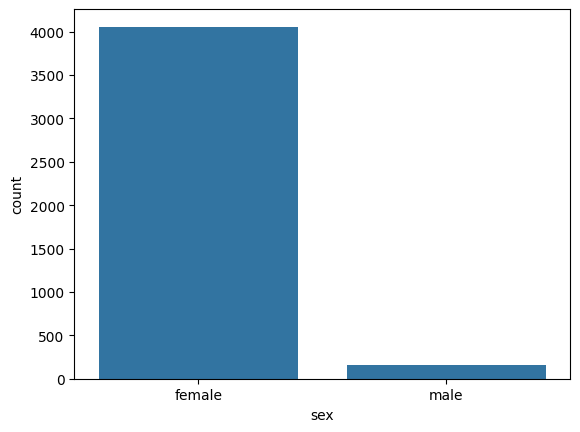

In [183]:
sns.countplot(data=df, x='sex')

**Insight**

* The Females are getting more affected by COVID-19 as they have about 4057 confirmed cases while the Males have only 155 confirmed cases.

**Reset birth_year to January 1st of respective years and convert them to date-time format from String**

In [184]:
df['birth_year_dt'] = pd.to_datetime(df['birth_year'], format='%Y')
df['birth_year_dt']


,birth_year_dt
0,1984-01-01
1,1964-01-01
2,1966-01-01
3,1964-01-01
4,1987-01-01
...,...
4207,1972-01-01
4208,1972-01-01
4209,1972-01-01
4210,1972-01-01


**Covert date in String to date-time format**

In [185]:
df['confirmed_date_dt'] = pd.to_datetime(df['confirmed_date'], format='%Y-%m-%d')
df['confirmed_date_dt']

,confirmed_date_dt
0,2020-01-20
1,2020-01-24
2,2020-01-26
3,2020-01-27
4,2020-01-30
...,...
4207,2020-03-01
4208,2020-03-01
4209,2020-03-01
4210,2020-03-01


**Difference of these two dates and floor division by 365 gives age of the person who is getting infected**

In [186]:
df['age_affected'] = (df['confirmed_date_dt'] - df['birth_year_dt']).dt.days // 365
df['age_affected']


,age_affected
0,36
1,56
2,54
3,56
4,33
...,...
4207,48
4208,48
4209,48
4210,48


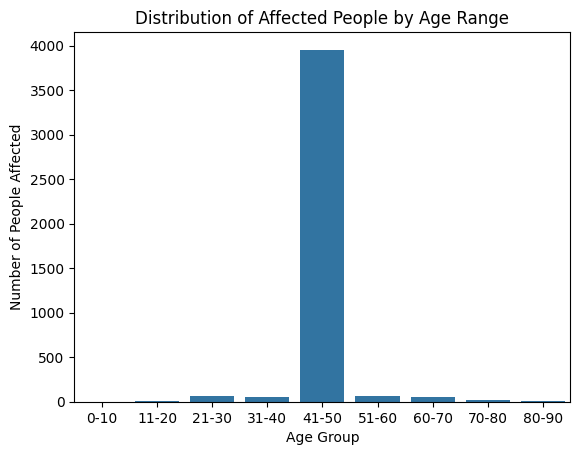

In [187]:
bins = [0, 10, 20, 30, 40, 50, 60,70,80,90]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '60-70','70-80','80-90']
df['Age Group'] = pd.cut(df['age_affected'], bins=bins, labels=labels)

sns.countplot(data=df, x='Age Group')

plt.title('Distribution of Affected People by Age Range')
plt.xlabel('Age Group')
plt.ylabel('Number of People Affected')
plt.show()

**Insight**

* From the Analysis we can observe that people of age 41-50 years are affected with most no.of COVID-19 diesease(approx. 4000 people).



In [188]:
infected_country = df['country'].value_counts()
infected_country

,count
country,
Korea,4203
China,8
Mongolia,1


<Axes: xlabel='country', ylabel='count'>

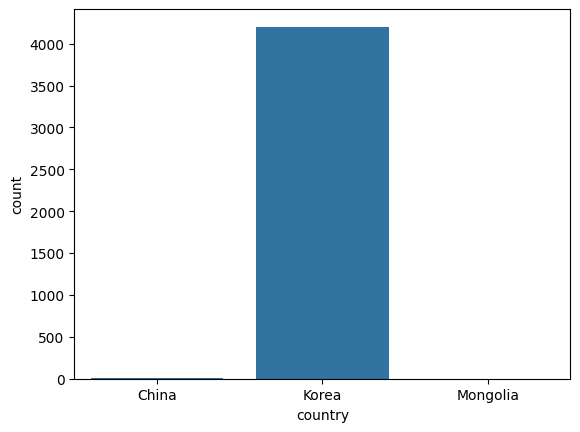

In [189]:
sns.countplot(data=df, x='country')

**Insight**

* From the Analysis, Korea has the most no.of COVID-19 cases reported(approx. 4000 cases).

2. **How are infections spreading?**

* Most common infection affecting reason

infection_reason
contact with patient                 4148
visit to Daegu                         40
visit to Wuhan                          8
pilgrimage to Israel                    6
contact with patient in Singapore       2
residence in Wuhan                      2
visit to Thailand                       2
contact with patient in Japan           1
visit to China                          1
visit to Vietnam                        1
visit to Cheongdo Daenam Hospital       1
Name: count, dtype: int64


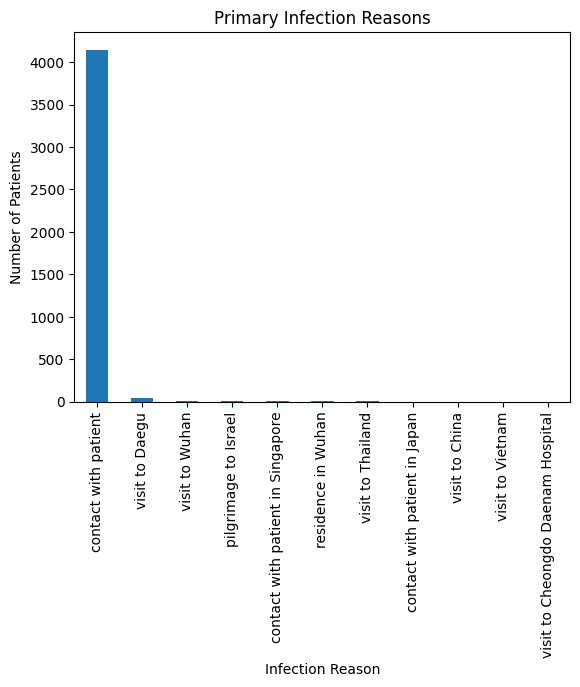

In [190]:
reason_count = df['infection_reason'].value_counts()

print(reason_count)

reason_count.plot(kind='bar')

plt.title("Primary Infection Reasons")
plt.xlabel("Infection Reason")
plt.ylabel("Number of Patients")
plt.show()

* Infection spread by Infection Order

In [191]:
spread_analysis = (
    df.groupby(["region", "infection_reason", "infection_order"])
      .size()
      .reset_index(name="Cases")
)

print(spread_analysis)

                 region                   infection_reason  infection_order  \
0                 Busan               contact with patient              2.0   
1     Chungcheongbuk-do               contact with patient              2.0   
2     Chungcheongnam-do               contact with patient              2.0   
3                 Daegu               contact with patient              2.0   
4                 Daegu                     visit to Daegu              2.0   
5               Daejeon               contact with patient              2.0   
6               Daejeon                     visit to Daegu              2.0   
7            Gangwon-do               contact with patient              2.0   
8            Gangwon-do                     visit to Daegu              2.0   
9               Gwangju               contact with patient              2.0   
10              Gwangju                     visit to Daegu              2.0   
11              Gwangju                  visit to Th

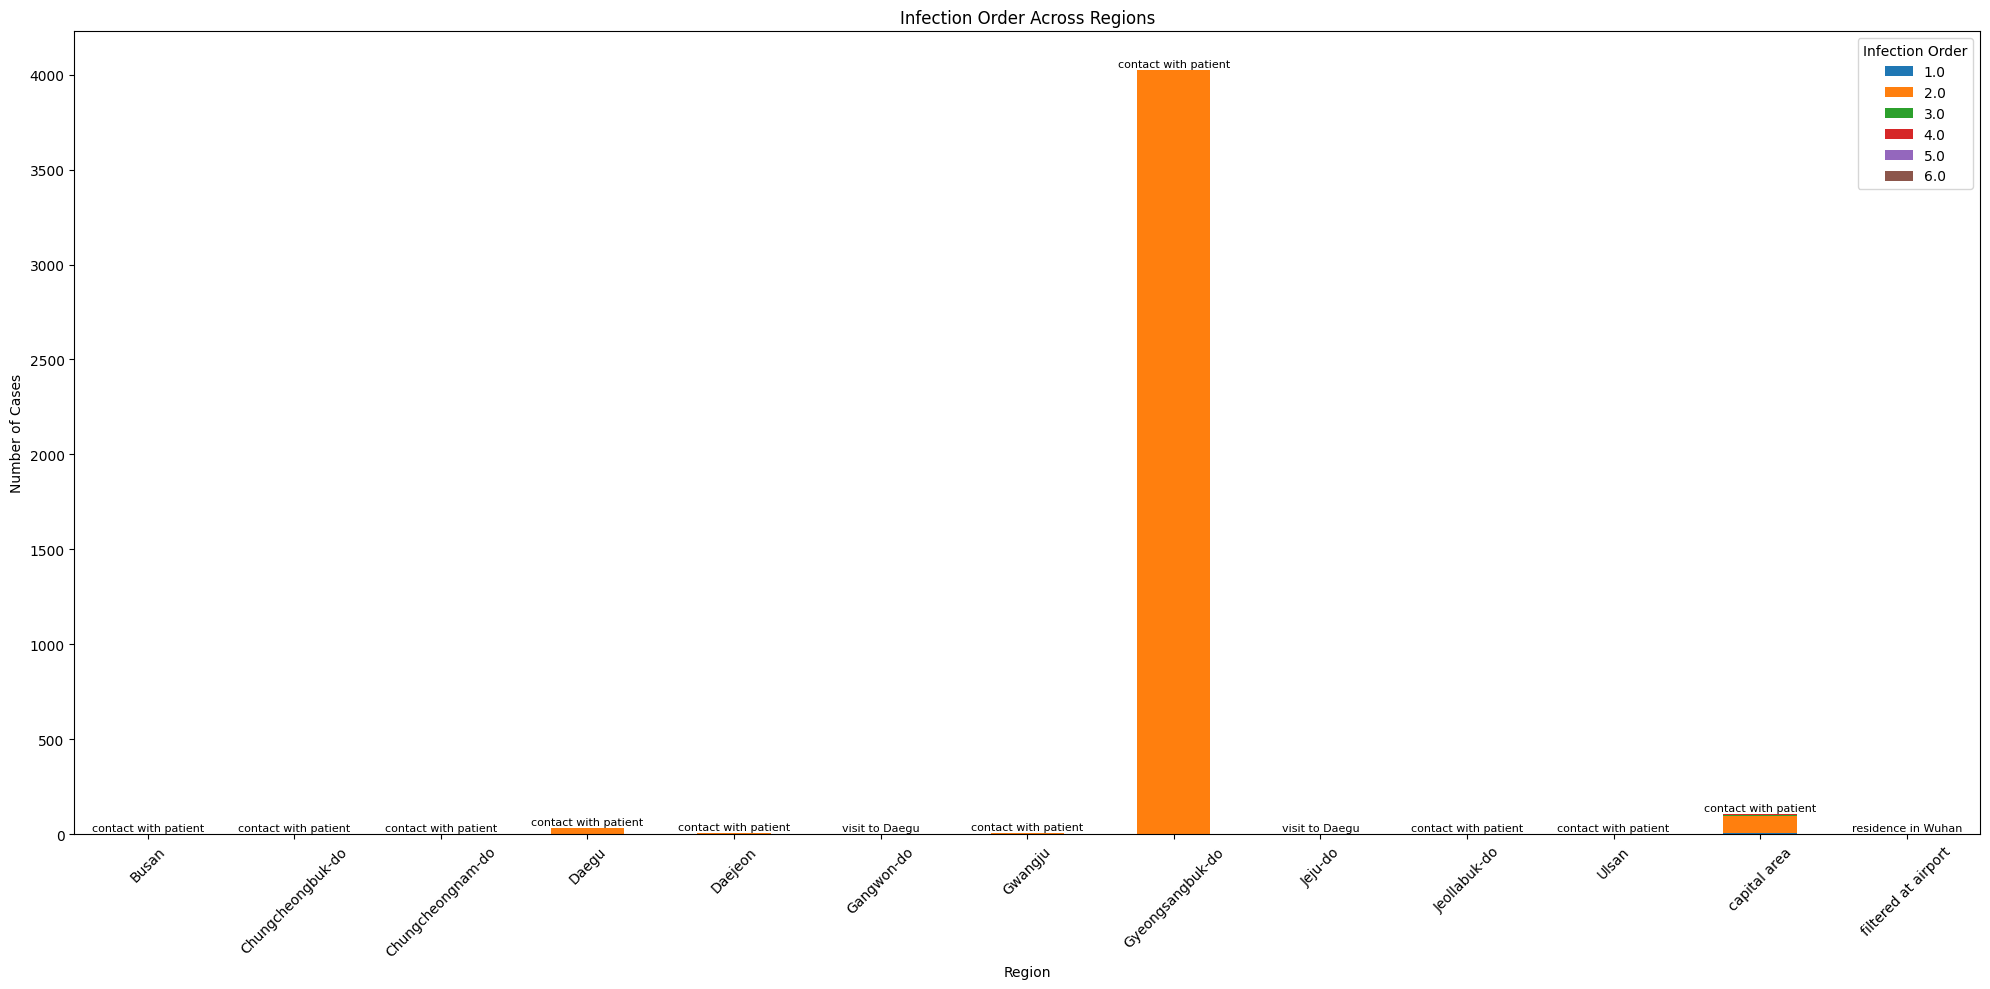

In [192]:
table = pd.crosstab(
    df["region"],
    df["infection_order"]
)

# Plot stacked bars
ax = table.plot(
    kind="bar",
    stacked=True,
    figsize=(20,10)
)

# Find the most common infection reason for each region
top_reason = (
    df.groupby("region")["infection_reason"]
      .agg(lambda x: x.mode().iloc[0])
)

# Total height of each stacked bar
totals = table.sum(axis=1)

# Write infection reason above each bar
for i, region in enumerate(table.index):
    ax.text(
        x=i,
        y=totals.iloc[i] + 5,           # Slightly above the bar
        s=top_reason.loc[region],
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=0
    )

plt.title("Infection Order Across Regions")
plt.xlabel("Region")
plt.ylabel("Number of Cases")
plt.legend(title="Infection Order")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights**
* From the Analysis, most cases occur from the region Gyeongsangbuk-do in the country Korea(4007 cases) with an infection order of 2 indicating that infection is spreading across this region when coming in contact with a patient of infected order 1.

In [193]:
print(df["contact_number"].describe())

count    4212.000000
mean       17.110399
std        20.500521
min         0.000000
25%        16.500000
50%        16.500000
75%        16.500000
max      1160.000000
Name: contact_number, dtype: float64


**Creating a new column Exposure_Level with respect to number of contacts**

In [194]:
def exposure_level(x):
    if pd.isna(x):
        return "Unknown"
    elif x <= 5:
        return "Low Exposure"
    elif x <= 20:
        return "Medium Exposure"
    else:
        return "High Exposure"

df["Exposure_Level"] = df["contact_number"].apply(exposure_level)

print(df["Exposure_Level"].value_counts())

Exposure_Level
Medium Exposure    4188
High Exposure        15
Low Exposure          9
Name: count, dtype: int64


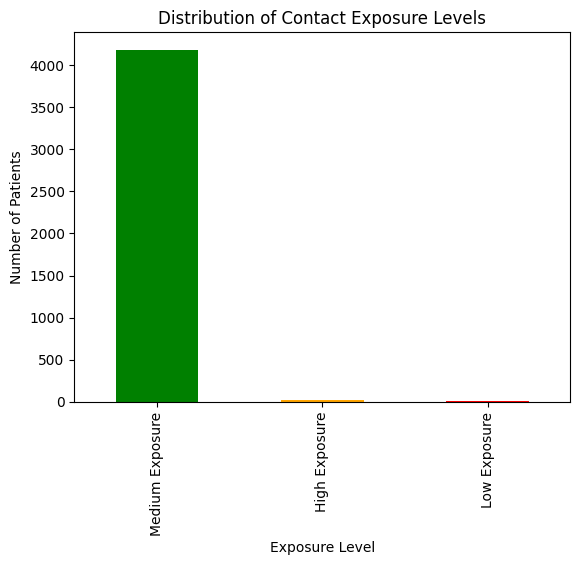

In [195]:
import matplotlib.pyplot as plt

exposure = df["Exposure_Level"].value_counts()

exposure.plot(
    kind="bar",
    color=["green","orange","red"]
)

plt.title("Distribution of Contact Exposure Levels")
plt.xlabel("Exposure Level")
plt.ylabel("Number of Patients")
plt.show()

**Insight**
* From this Analysis, we can observe that people with moderate number of contacts have recorded to be having the highest number of cases(4188 cases) while the people with high and low contact numbers have recorded to be having less cases(15 and 9 cases).

**Exposure Level V/s Infection order**

In [196]:
table = pd.crosstab(
    df["Exposure_Level"],
    df["infection_order"]
)

print(table)

infection_order  1.0   2.0  3.0  4.0  5.0  6.0
Exposure_Level                                
High Exposure      8     4    1    1    1    0
Low Exposure       3     3    3    0    0    0
Medium Exposure    2  4180    2    2    1    1


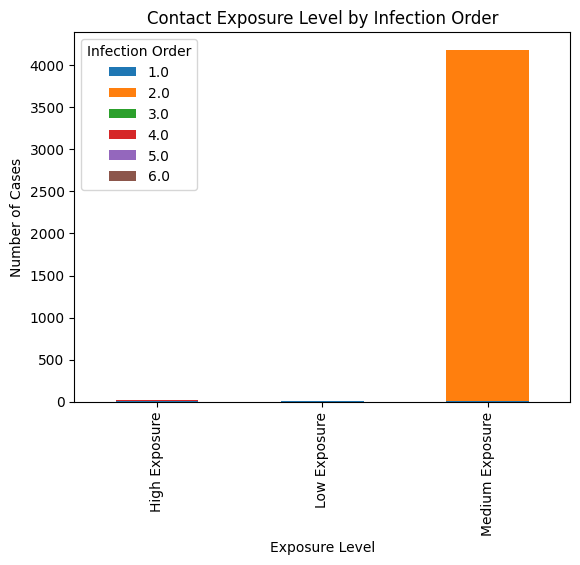

In [197]:
table.plot(
    kind="bar",
    stacked=True,

)

plt.title("Contact Exposure Level by Infection Order")
plt.xlabel("Exposure Level")
plt.ylabel("Number of Cases")
plt.legend(title="Infection Order")
plt.show()

**Insight**
* From this Analysis ,we can observe that 4180 cases have medium exposure with 2nd order of infection.

3. **What are the recovery trends?**

In [198]:
df['confirmed_date'] = pd.to_datetime(df['confirmed_date'], format='%Y-%m-%d')
df['released_date'] = pd.to_datetime(df['released_date'], format='%Y-%m-%d')

df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days

print(df['recovery_days'])


0       17.0
1       12.0
2       17.0
3       13.0
4        NaN
        ... 
4207     NaN
4208     NaN
4209     NaN
4210     NaN
4211     NaN
Name: recovery_days, Length: 4212, dtype: float64


**Insight**
* Here the NaN indicates that some of the confirmed patients are still not released from hospitals or there is no record of them being released.

**Remove unreleased patients**

In [199]:
recovered = df.dropna(subset=["recovery_days"])
print(np.floor(recovered['recovery_days'].describe()))

count    28.0
mean     15.0
std       5.0
min       7.0
25%       9.0
50%      16.0
75%      19.0
max      24.0
Name: recovery_days, dtype: float64


**Insight**
* The Average Recovery Time possible was recorded as 15 days
* The Fastest Recovery Time possible was recorded as 7 days
* The Slowest Recovery Time possible was recorded as 24 days

**Recovery By Region**

In [200]:
region_recovery = (
    recovered.groupby("region")["recovery_days"]
             .mean()
             .sort_values()
)

print(np.floor(region_recovery))

region
Daegu                   7.0
Gyeongsangbuk-do        8.0
Jeollabuk-do           12.0
Gwangju                12.0
capital area           16.0
filtered at airport    18.0
Name: recovery_days, dtype: float64


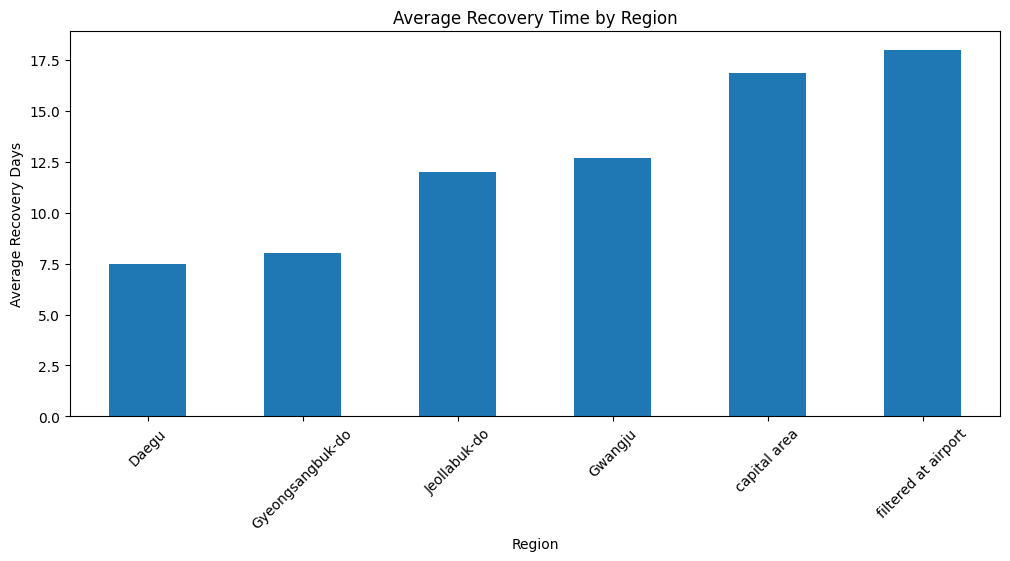

In [201]:
region_recovery.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Average Recovery Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Recovery Days")
plt.xticks(rotation=45)

plt.show()

**Insight**
* From this Analysis, we can observe that cases confirmed while filtering at the airport of each countries have the highest Average Recovery Time(18 days).

In [202]:
recovered = df.dropna(subset=["recovery_days"]).copy()

current_year = 2020

recovered["age"] = current_year - recovered["birth_year"]

bins = [0,20,40,60,80,120]
labels = ["0-20","21-40","41-60","61-80","80+"]

recovered["Age_Group"] = pd.cut(
    recovered["age"],
    bins=bins,
    labels=labels
)

age_recovery = (
    recovered.groupby("Age_Group",observed="False")["recovery_days"]
             .mean()
)

print(np.floor(age_recovery))

Age_Group
21-40    15.0
41-60    15.0
61-80     9.0
Name: recovery_days, dtype: float64


**Insight**
* People between the age 21-60 has the highest Average Recovery Time(15 days)

4. Which regions are most impacted?

**Count confirmed cases by region**

In [203]:
confirmed = (
    df.groupby("region")
      .size()
      .reset_index(name="Confirmed_Cases")
)

print(confirmed)

                 region  Confirmed_Cases
0                 Busan                2
1     Chungcheongbuk-do                2
2     Chungcheongnam-do                2
3                 Daegu               34
4               Daejeon               10
5            Gangwon-do                5
6               Gwangju               10
7      Gyeongsangbuk-do             4026
8               Jeju-do                2
9          Jeollabuk-do                4
10                Ulsan                2
11         capital area              109
12  filtered at airport                4


**Count released cases by region**

In [204]:
released = (
    df[df["released_date"].notna()]
      .groupby("region")
      .size()
      .reset_index(name="Released_Cases")
)

print(released)

                region  Released_Cases
0                Daegu               2
1              Gwangju               3
2     Gyeongsangbuk-do               2
3         Jeollabuk-do               1
4         capital area              16
5  filtered at airport               4


**Merge both tables**

In [205]:
region_analysis = pd.merge(
    confirmed,
    released,
    on="region",
    how="left"
)

region_analysis["Released_Cases"] = region_analysis["Released_Cases"].fillna(0).astype(int)

print(region_analysis)

                 region  Confirmed_Cases  Released_Cases
0                 Busan                2               0
1     Chungcheongbuk-do                2               0
2     Chungcheongnam-do                2               0
3                 Daegu               34               2
4               Daejeon               10               0
5            Gangwon-do                5               0
6               Gwangju               10               3
7      Gyeongsangbuk-do             4026               2
8               Jeju-do                2               0
9          Jeollabuk-do                4               1
10                Ulsan                2               0
11         capital area              109              16
12  filtered at airport                4               4


**Calculate Recovery Rate**

In [206]:
region_analysis["Recovery_Rate"] = (
    region_analysis["Released_Cases"]
    / region_analysis["Confirmed_Cases"]
) * 100

print(region_analysis)

                 region  Confirmed_Cases  Released_Cases  Recovery_Rate
0                 Busan                2               0       0.000000
1     Chungcheongbuk-do                2               0       0.000000
2     Chungcheongnam-do                2               0       0.000000
3                 Daegu               34               2       5.882353
4               Daejeon               10               0       0.000000
5            Gangwon-do                5               0       0.000000
6               Gwangju               10               3      30.000000
7      Gyeongsangbuk-do             4026               2       0.049677
8               Jeju-do                2               0       0.000000
9          Jeollabuk-do                4               1      25.000000
10                Ulsan                2               0       0.000000
11         capital area              109              16      14.678899
12  filtered at airport                4               4     100

**Insight**
* From the Analysis, Gyeongsangbuk-do has the highest number of confirmed cases(4026) and also has one of the lowest number of released cases(2) with Recovery Rate of 0.05%.Hence this region is most impacted.Also capital area , Daegu , Gwangju and Daejeon are some of the other most impacted regions.              

5. **Can we identify factors influencing recovery time?**

**Influence of Age over Recovery Time**

In [207]:
df["confirmed_date"] = pd.to_datetime(df["confirmed_date"])
df["released_date"] = pd.to_datetime(df["released_date"])
df["recovery_days"] = (df["released_date"] - df["confirmed_date"]).dt.days
recovered = df.dropna(subset=["recovery_days"]).copy()
recovered["age"] = 2020 - recovered["birth_year"]

In [208]:
bins = [0,20,40,60,80,120]
labels = ["0-20","21-40","41-60","61-80","80+"]

recovered["Age_Group"] = pd.cut(
    recovered["age"],
    bins=bins,
    labels=labels
)

age_recovery = (
    recovered.groupby("Age_Group", observed=False)["recovery_days"]
             .mean()
)

print(np.floor(age_recovery))

Age_Group
0-20      NaN
21-40    15.0
41-60    15.0
61-80     9.0
80+       NaN
Name: recovery_days, dtype: float64


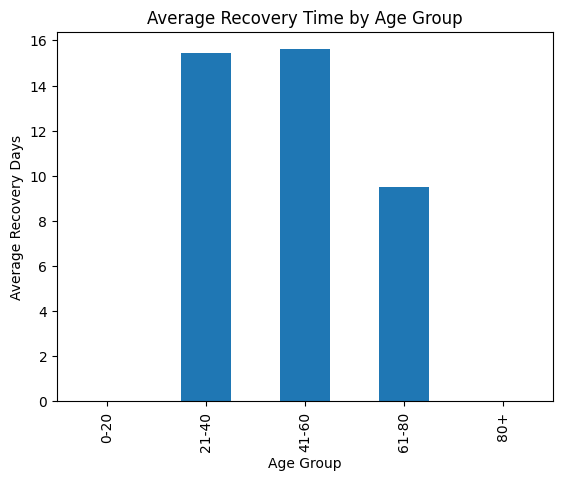

In [209]:
import matplotlib.pyplot as plt

age_recovery.plot(
    kind="bar",
)

plt.title("Average Recovery Time by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Recovery Days")

plt.show()

**Insight**
* From this Analysis, people between age group 21-60 requires 15 days and people between age group 61-80 requires 9 days to recover.Hence old people recover more fastly than young people according to the dataset.

****Influence of number of contacts over Recovery Time****

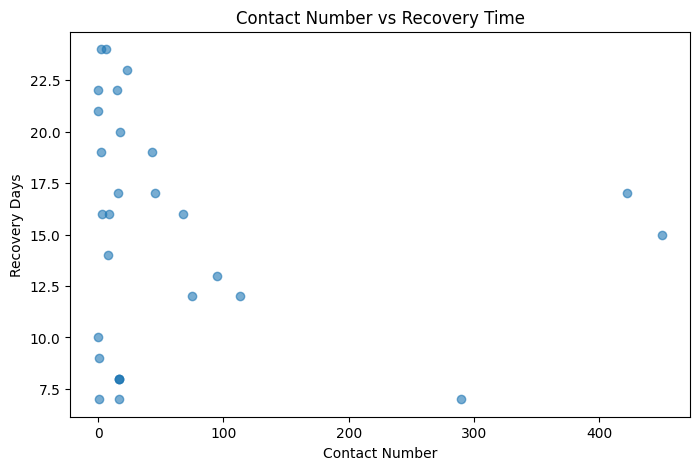

In [210]:
plt.figure(figsize=(8,5))

plt.scatter(
    recovered["contact_number"],
    recovered["recovery_days"],
    alpha=0.6
)

plt.title("Contact Number vs Recovery Time")
plt.xlabel("Contact Number")
plt.ylabel("Recovery Days")

plt.show()

**Insight**
* From this Analysis, we can observe that there is no strong linear relationship between the number of contacts a person had and their recovery time.

**Influence of Infection Order over Recovery Time**

In [211]:
order_recovery = (
    recovered.groupby("infection_order")["recovery_days"]
             .mean()
)

print(np.floor(order_recovery))

infection_order
1.0    16.0
2.0    12.0
3.0    17.0
Name: recovery_days, dtype: float64


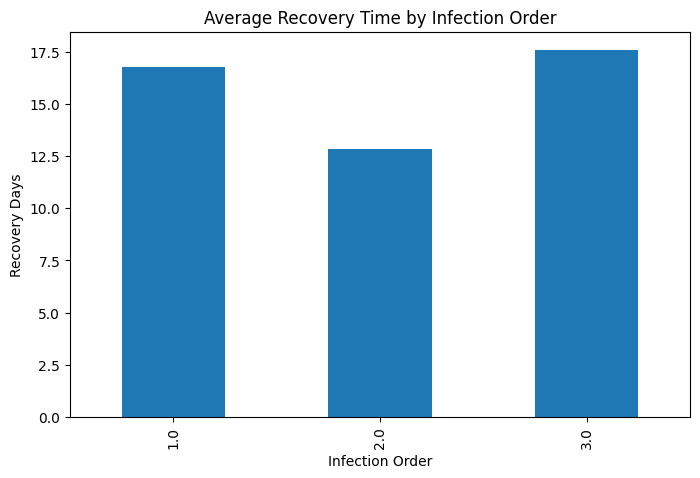

In [212]:
order_recovery.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Recovery Time by Infection Order")
plt.xlabel("Infection Order")
plt.ylabel("Recovery Days")

plt.show()

**Insight**
* From this Analysis, people with Infection Order 2 has the highest Recovery Time and people with Infection Order 3 has the lowest Recovery Time.

**Conclusions**
* The analysis indicates that the outbreak spread primarily through direct contact with infected individuals, resulting in a predominance of second-generation infections. The highest disease burden was concentrated in specific regions, particularly Gyeongsangbuk-do, highlighting regional variation in outbreak intensity. Most infected individuals had moderate contact exposure, and recovery generally occurred within two to three weeks after confirmation. Recovery duration appeared to vary with factors such as age and infection order, although further statistical analysis is required to confirm these relationships.
* Some of the improvements that can be done are:
  * Strengthen contact tracing
  * Focus resources on high-impact regions
  * Promote early detection
  * Protect high-risk groups
  * Continue public health measures
